# Policy Iteration: alternate evaluation and improvement

Policy Iteration evaluates a policy and then makes it greedy:

$$V^\pi(s)=\sum_{s',r}p(s',r\mid s,\pi(s))\left[r+\gamma(1-d)V^\pi(s')\right],\qquad
\pi_{new}(s)=\arg\max_a q^\pi(s,a).$$

Here $V^\pi$ is the current policy's value, $p$ the transition model, $\gamma$ the discount factor, $d$ the terminal indicator, and $q^\pi(s,a)$ the one-step action value. The process stops when improvement no longer changes the policy.

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

ENV_ID = "FrozenLake-v1"
GAMMA = 0.99
TOLERANCE = 1e-10
MAX_EVALUATION_SWEEPS = 10_000
MAX_IMPROVEMENTS = 100

env = gym.make(ENV_ID, is_slippery=True)
model = env.unwrapped.P
state_dim = env.observation_space.n
action_dim = env.action_space.n

## 1. Evaluate and improve

Policy evaluation repeatedly backs up only the selected action. Policy improvement computes every action value and chooses the largest.

In [2]:
def action_values(state, values):
    estimates = np.zeros(action_dim)
    for action in range(action_dim):
        for probability, next_state, reward, terminated in model[state][action]:
            bootstrap = 0.0 if terminated else values[next_state]
            estimates[action] += probability * (reward + GAMMA * bootstrap)
    return estimates


def evaluate_policy(policy, values):
    for _ in range(MAX_EVALUATION_SWEEPS):
        updated = np.array([
            action_values(state, values)[policy[state]] for state in range(state_dim)
        ])
        residual = np.max(np.abs(updated - values))
        values = updated
        if residual < TOLERANCE:
            break
    return values


def policy_iteration():
    policy = np.zeros(state_dim, dtype=np.int64)
    values = np.zeros(state_dim)
    changes = []
    for _ in range(MAX_IMPROVEMENTS):
        values = evaluate_policy(policy, values)
        improved = np.array([action_values(state, values).argmax() for state in range(state_dim)])
        changes.append(np.count_nonzero(improved != policy))
        if np.array_equal(improved, policy):
            policy = improved
            break
        policy = improved
    return values, policy, changes


values, policy, policy_changes = policy_iteration()
env.close()
print("Policy improvements:", len(policy_changes))
print("Greedy policy:\n", policy.reshape(4, 4))

Policy improvements: 7
Greedy policy:
 [[0 3 3 3]
 [0 0 0 0]
 [3 1 0 0]
 [0 2 1 0]]


## 2. Inspect policy stabilization

The number of changed actions falls to zero when the policy is stable. The value map describes that final policy.

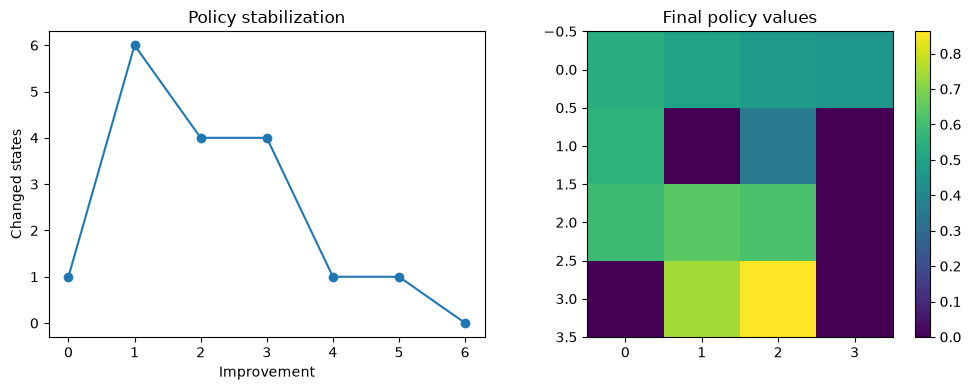

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(policy_changes, marker="o")
axes[0].set(xlabel="Improvement", ylabel="Changed states", title="Policy stabilization")
image = axes[1].imshow(values.reshape(4, 4), cmap="viridis")
axes[1].set(title="Final policy values")
fig.colorbar(image, ax=axes[1])
plt.tight_layout()
plt.show()

## 3. Watch the planned policy

This opens a separate rendered environment and follows the stable greedy policy for 5 episodes.

In [4]:
evaluation_env = gym.make(ENV_ID, render_mode="human", is_slippery=True)
episode_returns = []
try:
    for episode in range(5):
        state, _ = evaluation_env.reset(seed=10 + episode)
        total_reward = 0.0
        done = False
        while not done:
            state, reward, terminated, truncated, _ = evaluation_env.step(int(policy[state]))
            total_reward += reward
            done = terminated or truncated
        episode_returns.append(total_reward)
finally:
    evaluation_env.close()

print("Episode returns:", episode_returns)
print(f"Mean return: {np.mean(episode_returns):.2f}")

Episode returns: [1.0, 0.0, 1.0, 0.0, 1.0]
Mean return: 0.60
